In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
groq_api_key=os.getenv("GROQ_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [44]:
model="llama-3.3-70b-versatile"

In [45]:
from langchain_groq import ChatGroq
llm = ChatGroq(api_key=groq_api_key, model=model)

In [46]:
from langchain_community.tools.tavily_search import TavilySearchResults
search_tool = TavilySearchResults()

In [47]:
code = """
x=10
y=x+10
print(y)
"""


In [48]:
from langchain_experimental.utilities import PythonREPL
from typing import Annotated
from langchain_core.tools import tool
repl = PythonREPL()

In [49]:
@tool
def python_repl_tool(code: Annotated[str, "The python code to execute to generate your chart."]):
    """Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return result_str

In [50]:
python_repl_tool.invoke(code)

'Successfully executed:\n\\`\\`\\`python\n\nx=10\ny=x+10\nprint(y)\n\n\\`\\`\\`\nStdout: 20\n'

In [51]:
members=["researcher","coder"]
options = members+["FINISH"]

In [52]:
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import MessagesState,StateGraph,START, END

class Router(TypedDict):
    next: Literal['researcher', 'coder', 'FINISH']

class State(MessagesState):
    next: str

In [53]:
members

['researcher', 'coder']

In [54]:
system_prompt = f""""
You are a supervisor, tasked with managing a conversation between the following workers: {members}. 
Given the following user request, respond with the worker to act next. 
Each worker will perform a task and respond with their results and status. 
When finished, respond with FINISH.
"""

In [55]:
from langgraph.types import Command

def supervisor_agent(state: State) -> Command[Literal['researcher', 'coder', '__end__']]:
    # Here you would implement the logic to decide which worker should act next based on the state of the conversation and the user request.
    # For simplicity, we will just return 'researcher' for the first turn, then 'coder', and then 'FINISH'.
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    llm_with_strctured_output = llm.with_structured_output(Router)
    response = llm_with_strctured_output.invoke(messages)
    
    # next worker agent
    goto = response["next"]
    print(f"Supervisor decided to go to: {goto}")
    
    if goto == "FINISH":
        goto = "__end__"
    return Command(goto=goto, update={"next": goto})


In [67]:
from langchain.agents import create_agent
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

In [73]:
def research_agent(state: State) -> Command[Literal['supervisor']]:
    # Implement the logic for the researcher agent to perform research based on the user request and the conversation history.
    research_agent = create_agent(llm, tools=[search_tool], system_prompt="you are a researcher agent. DO NOT do any math")
    result = research_agent.invoke(state)
    
    return Command(
        goto="supervisor", 
        update={
            "messages": [HumanMessage(result["messages"][-1].content, name="researcher")]
        }
    )

In [74]:
def coder_agent(state: State) -> Command[Literal['supervisor']]:
    # Implement the logic for the coder agent to perform coding tasks based on the user request and the conversation history.
    coder_agent = create_agent(llm, tools=[search_tool], system_prompt="you are a coder agent. DO NOT do any math")
    result = coder_agent.invoke(state)
    
    return Command(
        goto="supervisor", 
        update={
            "messages": [HumanMessage(result["messages"][-1].content, name="coder")]
        }
    )

In [75]:
graph = StateGraph(State)
graph.add_node("supervisor", supervisor_agent)
graph.add_node("researcher", research_agent)
graph.add_node("coder", coder_agent)
graph.add_edge(START, "supervisor")
app = graph.compile()


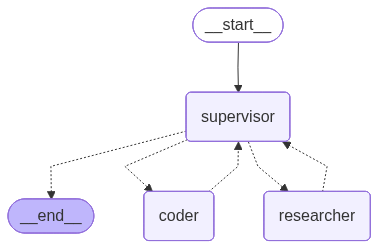

In [76]:
app

In [77]:
for s in app.stream(input={"messages": [HumanMessage("What is the capital of France?", name="user")]}):
    print(s)
    print("*****************************************")

Supervisor decided to go to: researcher
{'supervisor': {'next': 'researcher'}}
*****************************************
{'researcher': {'messages': [HumanMessage(content='The capital of France is Paris.', additional_kwargs={}, response_metadata={}, name='researcher', id='f1372b71-cfd3-4e80-946f-94e8811c7f0e')]}}
*****************************************
Supervisor decided to go to: researcher
{'supervisor': {'next': 'researcher'}}
*****************************************
{'researcher': {'messages': [HumanMessage(content='The capital of France is Paris.', additional_kwargs={}, response_metadata={}, name='researcher', id='5803ef6e-a01e-4250-801a-fb86ac7f02a3')]}}
*****************************************
Supervisor decided to go to: FINISH
{'supervisor': {'next': '__end__'}}
*****************************************


In [79]:
state

NameError: name 'state' is not defined